In [1]:
pip install opencv-python matplotlib numpy


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Display inline in Jupyter
%matplotlib inline


In [4]:
from google.colab import files

# Upload the image from your PC
uploaded = files.upload()

Saving imageproject.jpg to imageproject.jpg


✅ Image loaded successfully.


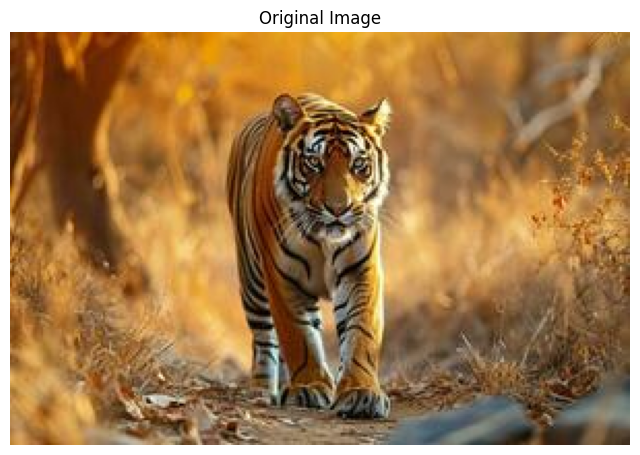

In [5]:
# Load the image
image_path = 'imageproject.jpg'  # Ensure this is the correct filename and in the right path
original_image = cv2.imread(image_path)

# Check if the image was loaded
if original_image is None:
    print("❌ Error: Could not load image. Check the file name or path.")
else:
    print("✅ Image loaded successfully.")

    # Convert from BGR to RGB for display
    image_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

    # Show original image
    plt.figure(figsize=(8, 6))
    plt.imshow(image_rgb)
    plt.title("Original Image")
    plt.axis('off')
    plt.show()



In [6]:
def preprocess_image(image, resize_width=None, blur_ksize=21):
    """
    Preprocesses the image for pencil sketch effect.

    Parameters:
        image (ndarray): Original BGR image.
        resize_width (int): Optional width to resize image.
        blur_ksize (int): Gaussian blur kernel size (must be odd).

    Returns:
        dict: Dictionary containing intermediate processing steps.
    """
    output = {}

    # Resize image while maintaining aspect ratio
    if resize_width:
        height, width = image.shape[:2]
        aspect_ratio = height / width
        new_height = int(resize_width * aspect_ratio)
        image = cv2.resize(image, (resize_width, new_height))
        print(f"✅ Image resized to {resize_width}x{new_height}")

    output['original'] = image.copy()

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    output['gray'] = gray

    # Invert the grayscale image
    inverted_gray = 255 - gray
    output['inverted_gray'] = inverted_gray

    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(inverted_gray, (blur_ksize, blur_ksize), 0)
    output['blurred'] = blurred

    # Invert the blurred image (for division later)
    inverted_blur = 255 - blurred
    output['inverted_blur'] = inverted_blur

    return output


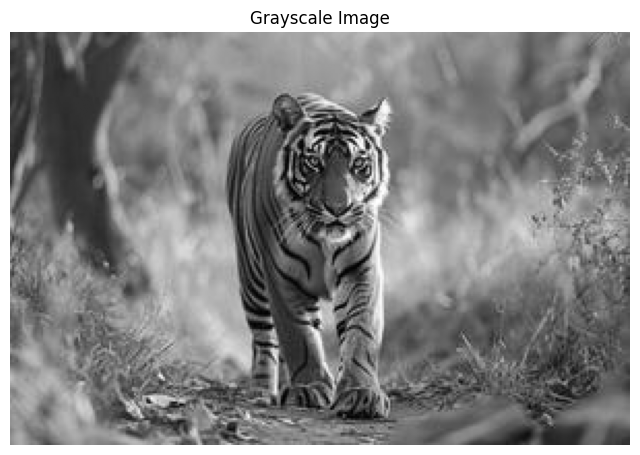

In [7]:
# Convert the image to grayscale
gray_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2GRAY)

# Show grayscale image
plt.figure(figsize=(8, 6))
plt.imshow(gray_image, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()


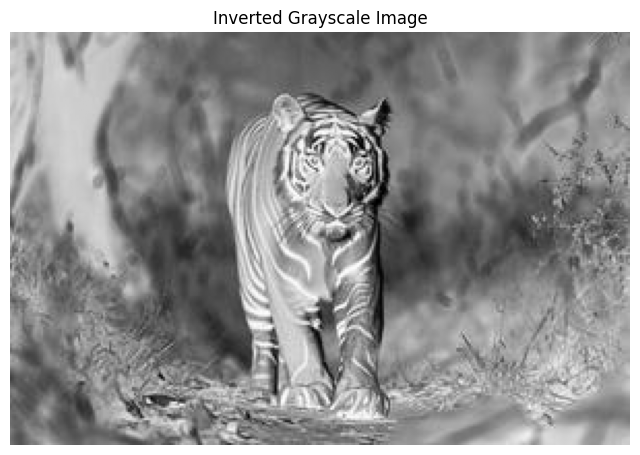

In [8]:
# Invert the grayscale image
inverted_gray = 255 - gray_image

# Show inverted image
plt.figure(figsize=(8, 6))
plt.imshow(inverted_gray, cmap='gray')
plt.title("Inverted Grayscale Image")
plt.axis('off')
plt.show()


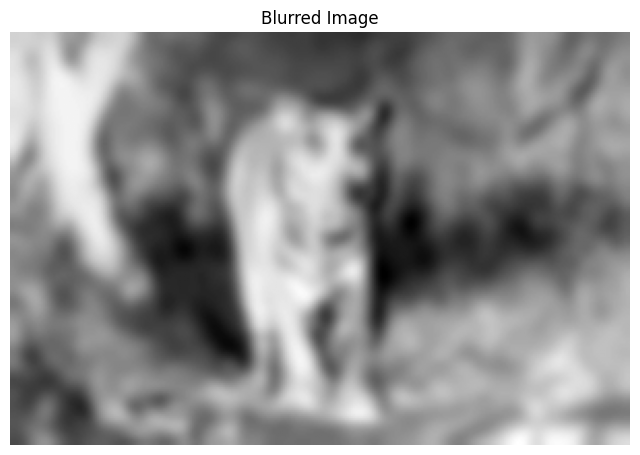

In [9]:
# Apply Gaussian blur
blurred = cv2.GaussianBlur(inverted_gray, (21, 21), sigmaX=0, sigmaY=0)

# Show blurred image
plt.figure(figsize=(8, 6))
plt.imshow(blurred, cmap='gray')
plt.title("Blurred Image")
plt.axis('off')
plt.show()


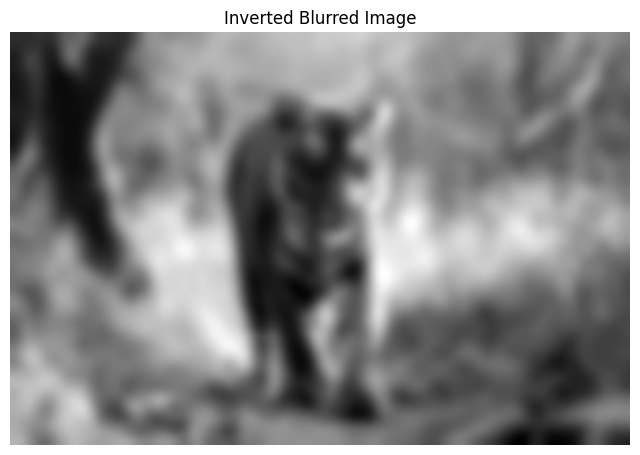

In [10]:
# Invert the blurred image
inverted_blur = 255 - blurred

# Show inverted blurred image
plt.figure(figsize=(8, 6))
plt.imshow(inverted_blur, cmap='gray')
plt.title("Inverted Blurred Image")
plt.axis('off')
plt.show()


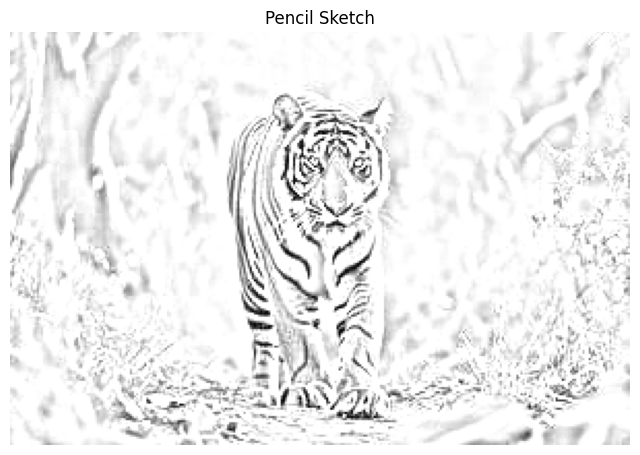

In [11]:
# Create the pencil sketch by dividing the grayscale image by the inverted blur
pencil_sketch = cv2.divide(gray_image, inverted_blur, scale=256.0)

# Show pencil sketch
plt.figure(figsize=(8, 6))
plt.imshow(pencil_sketch, cmap='gray')
plt.title("Pencil Sketch")
plt.axis('off')
plt.show()


In [12]:
# Save the pencil sketch image
cv2.imwrite('pencil_sketch.jpg', pencil_sketch)


True